# Modeling & Explainability

In this notebook, we build classification models predicting user conversion based on their user journey features. We will then explain the model using SHAP to infer channel attribution.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

c:\Users\priya\OneDrive\Documents\DS Internship\capstone-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'matplotlib'

## 2. Load Processed Data & Train/Test Split

In [ ]:
df = pd.read_csv('../data/processed_data.csv')

X = df.drop(columns=['CustomerID', 'converted', 'MonetaryValue'])
y = df['converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training shape: {X_train.shape}, Testing shape: {X_test.shape}')

Training shape: (3471, 39), Testing shape: (868, 39)


## 3. Baseline Models Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import os
import pickle

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}
os.makedirs('../model/checkpoints', exist_ok=True)

for name, model in models.items():
    model.fit(X_train, y_train)
    
    with open(f'../model/checkpoints/{name.replace(" ", "_").lower()}_checkpoint.pkl', 'wb') as f:
        pickle.dump(model, f)
        
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.887097,0.796875,0.586207,0.675497,0.926153
Random Forest,0.877880,0.729730,0.620690,0.670807,0.909777
XGBoost,0.881336,0.729032,0.649425,0.686930,0.900481


## 4. Hyperparameter Tuning (XGBoost)

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}

xgb_tuned = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
grid = GridSearchCV(estimator=xgb_tuned, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print('Best Parameters:', grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


## 5. Model Evaluation

FINAL MODEL EVALUATION (XGBoost Tuned)
Accuracy: 0.8755760368663594
Precision: 0.9342105263157895
Recall: 0.40804597701149425
F1 Score: 0.568
ROC-AUC: 0.9132755308224851


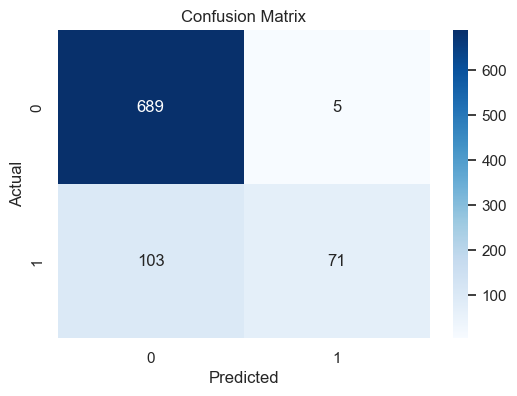

In [ ]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL EVALUATION (XGBoost Tuned)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Saving Final Model

In [ ]:
with open('../model/trained_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print('Model saved properly.')

Model saved properly.


## 7. Explainability: Feature Importance & SHAP

This helps us understand which marketing channels contribute the most to conversions.

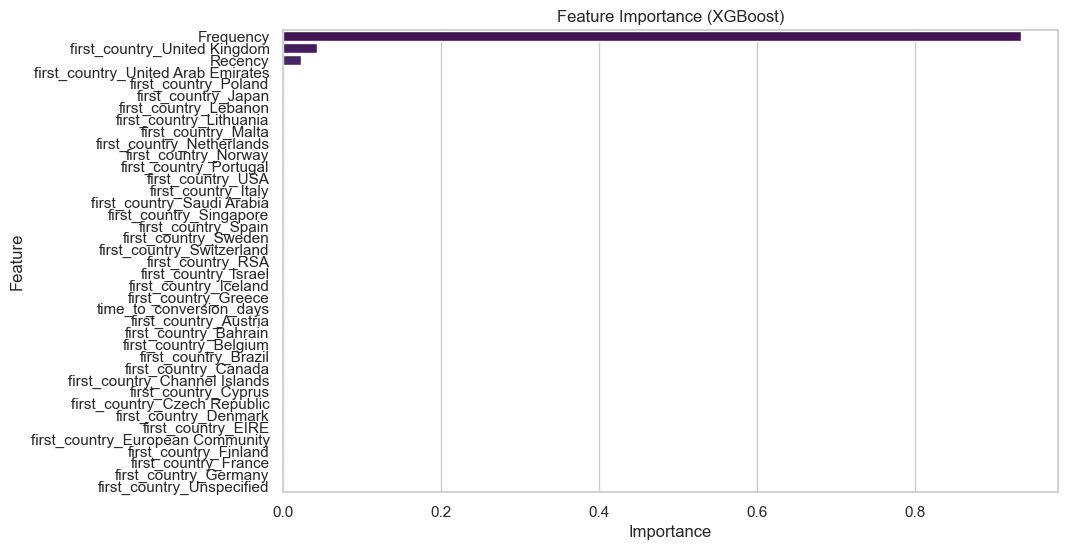

In [ ]:
# Traditional Feature Importance
feature_importances = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.show()

In [ ]:
# SHAP Values for Attribution
explainer = shap.TreeExplainer(models['Random Forest'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type='bar')
plt.show()



NameError: name 'models' is not defined